In [1]:
import sys
import os

import scanpy as sc
import scvelo as scv
import scvi

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from BigSur.feature_selection import mcfano_feature_selection

import h5py
from scipy.sparse import csr_matrix

from matplotlib.colors import ListedColormap

from scipy.stats import spearmanr
from scipy.stats import pearsonr
from scipy.stats import linregress
from scipy.stats import median_abs_deviation

import itertools

In [2]:
import matplotlib.pyplot as plt
from matplotlib import rc

# set style
plt.style.use('seaborn-v0_8-paper')

# set sizes
SMALL_SIZE = 5
MEDIUM_SIZE = 6
BIGGER_SIZE = 6

rc('font', size=MEDIUM_SIZE)          # controls default text sizes
rc('axes', titlesize=MEDIUM_SIZE)     # fontsize of the axes title
rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
rc('xtick', labelsize=MEDIUM_SIZE)    # fontsize of the tick labels
rc('ytick', labelsize=MEDIUM_SIZE)    # fontsize of the tick labels
rc('legend', fontsize=MEDIUM_SIZE)    # legend fontsize
rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

# set font
rc('font', **{'family':'serif','serif':['Arial']})
rc('svg', **{'fonttype':'none'})

# one more change to axes and tick widths
rc('axes', **{'linewidth': 0.5, 'labelpad': 2.5})

rc('xtick', **{'major.width': 0.5, 'minor.width': 0.5, 'major.pad': 2.5})
rc('ytick', **{'major.width': 0.5, 'minor.width': 0.5, 'major.pad': 2.5})

import matplotlib.cm as cm
import matplotlib.colors as mcolors

In [3]:
path_out_dir = 'figures'

# read data
paths = [
    '/home/data/Shared/shared_datasets/sc_rna_seq/nlaszik/tko_atrinh_122923/TKO1_count_hg19/outs/filtered_feature_bc_matrix.h5',
    '/home/data/Shared/shared_datasets/sc_rna_seq/nlaszik/tko_atrinh_122923/TKO2_count_hg19/outs/filtered_feature_bc_matrix.h5'
    
]
names = ['TKO Rep1', 'TKO Rep2']
sources = ['Source 1', 'Source 1']
dataset='tko_with_velo'

loom_paths = [
    '/home/data/Shared/shared_datasets/sc_rna_seq/nlaszik/tko_atrinh_122923/TKO1_count_hg19/velocyto/TKO1_count_hg19.loom',
    '/home/data/Shared/shared_datasets/sc_rna_seq/nlaszik/tko_atrinh_122923/TKO2_count_hg19/velocyto/TKO2_count_hg19.loom'
]

sample_info = pd.DataFrame({
    'sample_path': paths,
    'sample_name': names,
    'loom_path': loom_paths,
    'sample_source': sources
})

print(sample_info)

                                         sample_path sample_name  \
0  /home/data/Shared/shared_datasets/sc_rna_seq/n...    TKO Rep1   
1  /home/data/Shared/shared_datasets/sc_rna_seq/n...    TKO Rep2   

                                           loom_path sample_source  
0  /home/data/Shared/shared_datasets/sc_rna_seq/n...      Source 1  
1  /home/data/Shared/shared_datasets/sc_rna_seq/n...      Source 1  


In [4]:
def sc_preprocess(path: str, path_loom: str):
    
    if path.endswith('.h5ad'):
        adata = sc.read_h5ad(path)
    else:
        adata = sc.read_10x_h5(path)
    
    adata.var_names_make_unique()
    
    ldata = sc.read(path_loom)
    adata = scv.utils.merge(adata, ldata)

    # Generate qc metrics
    adata.var["mt"] = adata.var_names.str.startswith("MT-")

    sc.pp.calculate_qc_metrics(
        adata, 
        qc_vars=["mt"], 
        inplace=True, percent_top=[20], 
        log1p=True
        )
    
    print(path)
    sc.pl.violin(
        adata,
        ["log1p_total_counts", "log1p_n_genes_by_counts", "pct_counts_in_top_20_genes", "pct_counts_mt"],
        jitter=0.4,
        multi_panel=True,
    )
    
    # Identify outliers per qc metric
    adata.obs["counts_outlier"] = is_outlier(adata, "log1p_total_counts", 5)
    adata.obs["genes_outlier"] = is_outlier(adata, "log1p_n_genes_by_counts", 5)
    adata.obs["topgenes_outlier"] = is_outlier(adata, "pct_counts_in_top_20_genes", 5)
    adata.obs["mito_outlier"] = is_outlier(adata, "pct_counts_mt", 3) | (adata.obs["pct_counts_mt"] <= 1)

    # Identify outliers based on ALL qc metrics 
    adata.obs["outlier"] = (
        adata.obs["counts_outlier"]  
        | adata.obs["genes_outlier"] 
        | adata.obs["topgenes_outlier"] 
        | adata.obs["mito_outlier"]
    )
    # Remove outliers
    adata = adata[~adata.obs["outlier"]].copy()
    
    # Remove non-developmental genes
    mt_genes = adata.var_names[adata.var_names.str.startswith('MT-')]
    rpl_genes = adata.var_names[adata.var_names.str.startswith('RPL')]
    rps_genes = adata.var_names[adata.var_names.str.startswith('RPS')]
    hist_genes = adata.var_names[adata.var_names.str.startswith('HIST')]
    rna_genes = adata.var_names[adata.var_names.str.startswith('RNA')]
    
    remove_genes = list(mt_genes) + list(rpl_genes) + list(rps_genes) + list(hist_genes) + list(rna_genes)
    adata = adata[:, ~adata.var_names.isin(remove_genes)]

    # This is from the scvelo documentation
    #scv.pp.filter_and_normalize(adata, min_shared_counts=20, n_top_genes=2000)
    #scv.pp.moments(adata, n_pcs=30, n_neighbors=30)

    # Perform gene filtering
    sc.pp.filter_genes(adata, min_cells=3)

    # doublets
    sc.pp.scrublet(adata)
    
    adata.layers["counts"] = adata.X.copy()  # preserve counts

    return adata

# our outlier detection function from before
def is_outlier(adata, metric: str, nmads: int):
    M = adata.obs[metric]
    outlier = (M < np.median(M) - nmads * median_abs_deviation(M)) | (
            np.median(M) + nmads * median_abs_deviation(M) < M
    )
    
    print(f'{metric}: {np.median(M) - nmads * median_abs_deviation(M)} - {np.median(M) + nmads * median_abs_deviation(M)}')
    
    return outlier

In [5]:
# LOAD PROCESSED DATA
fn = f'scvi_integrated_{dataset}.h5ad'
adata_concat = sc.read_h5ad(fn)

In [8]:
print(adata_concat.var['mc_Fano'])

adj_fano = adata_concat.var['mc_Fano']

print(adj_fano.loc[adj_fano.index == 'NR2F2'])

5S_rRNA-1     0.929770
7SK-3         1.457593
7SK-4         1.106784
7SK-5         0.908051
A1BG          1.165398
                ...   
snoU13-417    0.980386
snoU13-440    0.789113
snoU13-54     1.014753
snoU13-66     0.953121
snoU13-79     0.925220
Name: mc_Fano, Length: 26055, dtype: float64
NR2F2    3.230789
Name: mc_Fano, dtype: float64



Reading TKO Rep1


/home/nlaszik/venvs/bigsur/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/nlaszik/venvs/bigsur/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/nlaszik/venvs/bigsur/lib/python3.10/site-packages/anndata/utils.py:264: UserWarning: Suffix used (-[0-9]+) to deduplicate index values may make index values difficult to interpret. There values with a similar suffixes in the index. Consider using a different delimiter by passing `join={delimiter}`Example key collisions generated by the make_index_unique algorithm: ['SNORD116-1', 'SNORD116-2', 'SNORD116-3', 'SNORD116-5', 'SNORD116-6']
  warnings.warn(
/home/nlaszik/venvs/bigsur/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning:

/home/data/Shared/shared_datasets/sc_rna_seq/nlaszik/tko_atrinh_122923/TKO1_count_hg19/outs/filtered_feature_bc_matrix.h5


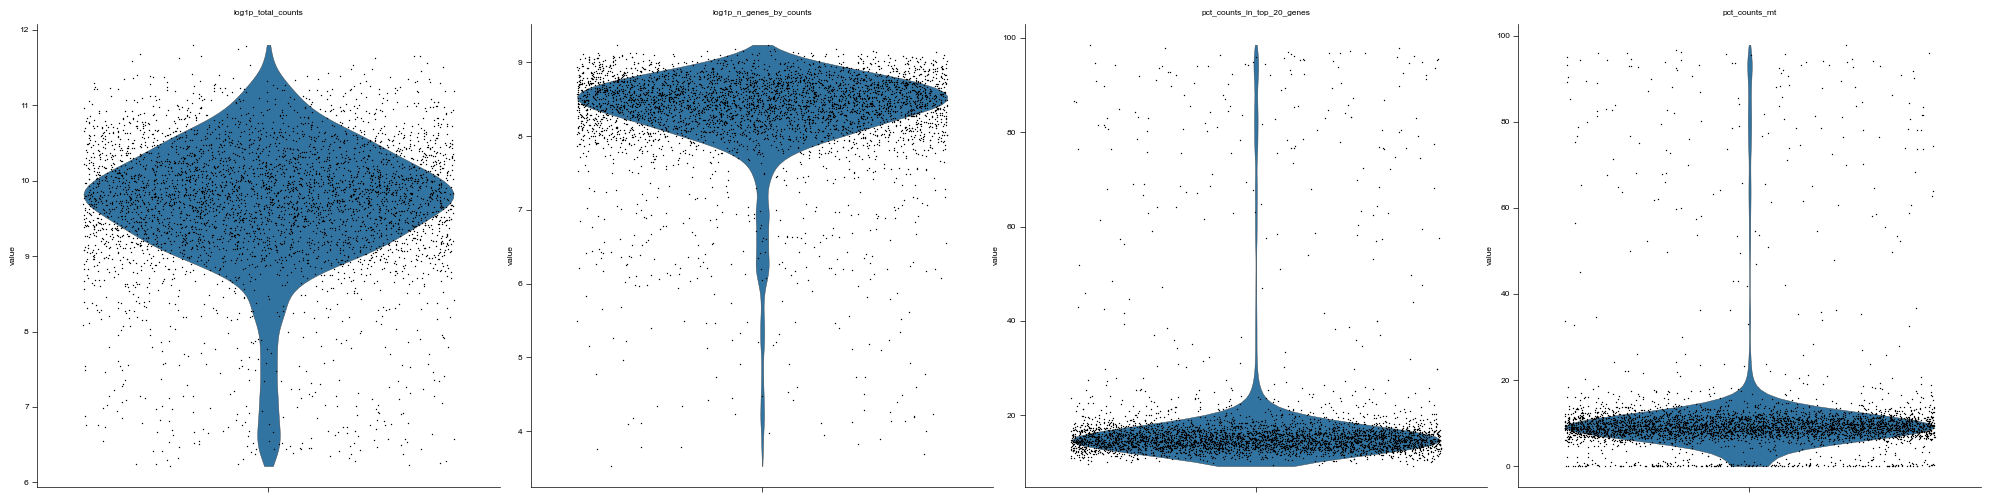

log1p_total_counts: 7.391244888305664 - 12.144777297973633
log1p_n_genes_by_counts: 7.165770789453202 - 9.712260031251226
pct_counts_in_top_20_genes: 7.503221065811939 - 22.293062793601536
pct_counts_mt: 4.491055488586426 - 13.776442527770996


/home/nlaszik/venvs/bigsur/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:278: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["n_cells"] = number



Reading TKO Rep2


/home/nlaszik/venvs/bigsur/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/nlaszik/venvs/bigsur/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/nlaszik/venvs/bigsur/lib/python3.10/site-packages/anndata/utils.py:264: UserWarning: Suffix used (-[0-9]+) to deduplicate index values may make index values difficult to interpret. There values with a similar suffixes in the index. Consider using a different delimiter by passing `join={delimiter}`Example key collisions generated by the make_index_unique algorithm: ['SNORD116-1', 'SNORD116-2', 'SNORD116-3', 'SNORD116-5', 'SNORD116-6']
  warnings.warn(
/home/nlaszik/venvs/bigsur/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning:

/home/data/Shared/shared_datasets/sc_rna_seq/nlaszik/tko_atrinh_122923/TKO2_count_hg19/outs/filtered_feature_bc_matrix.h5


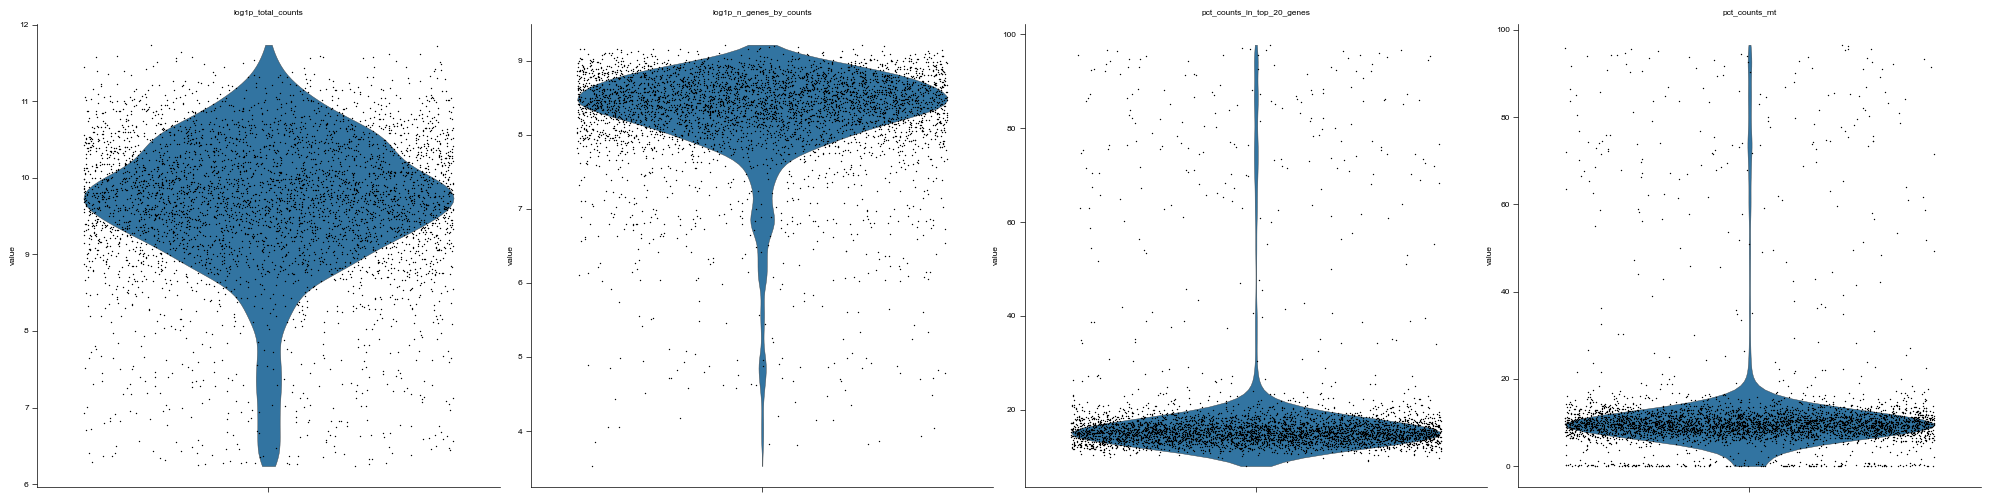

log1p_total_counts: 7.083519458770752 - 12.372783184051514
log1p_n_genes_by_counts: 7.037207621106149 - 9.801953103992325
pct_counts_in_top_20_genes: 7.385551360155195 - 23.0855838025124
pct_counts_mt: 4.636226654052734 - 14.451412200927734


/home/nlaszik/venvs/bigsur/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:278: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["n_cells"] = number


In [20]:
# create a dictionary to hold all AnnData objects
adata = dict.fromkeys(sample_info["sample_name"])

# read all samples
for sample in adata.keys():
    print(f"\nReading {sample}")
    sample_path = sample_info.loc[sample_info['sample_name'] == sample, 'sample_path'].values[0]
    loom_path = sample_info.loc[sample_info['sample_name'] == sample, 'loom_path'].values[0]
    adata[sample] = sc_preprocess(sample_path, loom_path)

In [21]:
# grab all var DataFrames from our dictionary
all_var = [x.var for x in adata.values()]
# concatenate them
all_var = pd.concat(all_var, join="outer")
# remove duplicates
all_var = all_var[~all_var.index.duplicated()]

adata = sc.concat(adata, join="outer", label="sample_name", index_unique="-")

adata.var = all_var.loc[adata.var_names]

adata.obs = (
  adata.obs
  .merge(sample_info, how="left", on="sample_name")
  .set_axis(adata.obs.index)
)

adata.obs.drop(columns=['predicted_doublet'], inplace=True)

In [22]:
adata_concat = adata

In [23]:
###########################
# SCVI
###########################

sc.pp.normalize_total(adata_concat, target_sum=1e4)
sc.pp.log1p(adata_concat)
adata_concat.raw = adata_concat  # keep full dimension safe

mcfano_feature_selection(adata_concat, layer='counts', cv=None, verbose=1) # Fit CV

scvi.model.SCVI.setup_anndata(
    adata_concat,
    layer="counts",
    categorical_covariate_keys=["sample_source", "sample_name"]
)

scvi_model = scvi.model.SCVI(adata_concat)
scvi_model.train()

Using 0.01 for pvalue cutoff and 0.95 for mcfano quantile cutoff for highly variable genes.
After fitting, cv = 0.3


/home/nlaszik/venvs/bigsur/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/nlaszik/venvs/bigsur/lib/python3.10/site-packa ...
/home/nlaszik/venvs/bigsur/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/nlaszik/venvs/bigsur/lib/python3.10/site-packa ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/nlaszik/venvs/bigsur/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention 

Epoch 400/400: 100%|██████████| 400/400 [05:28<00:00,  1.35s/it, v_num=1, train_loss_step=1.23e+4, train_loss_epoch=1.18e+4]

`Trainer.fit` stopped: `max_epochs=400` reached.


Epoch 400/400: 100%|██████████| 400/400 [05:28<00:00,  1.22it/s, v_num=1, train_loss_step=1.23e+4, train_loss_epoch=1.18e+4]


In [24]:
# Integrate SCVI Model Parameters
# This is already done in loaded data, no need to run again

SCVI_LATENT_KEY = "X_scVI"
adata_concat.obsm[SCVI_LATENT_KEY] = scvi_model.get_latent_representation()

SCVI_NORMALIZED_KEY = "scvi_normalized"
adata_concat.layers[SCVI_NORMALIZED_KEY] = scvi_model.get_normalized_expression(library_size=10e4)

In [25]:
SCVI_LATENT_KEY = "X_scVI"

sc.tl.pca(adata_concat)
sc.pp.neighbors(adata_concat, use_rep=SCVI_LATENT_KEY)
sc.tl.umap(adata_concat, min_dist=0.05)

In [26]:
scv.pp.moments(adata_concat, n_pcs=30, n_neighbors=30)

Normalized count data: spliced, unspliced.
computing neighbors


/tmp/ipykernel_107365/1770959900.py:1: DeprecationWarning: Automatic neighbor calculation is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors first with Scanpy.
  scv.pp.moments(adata_concat, n_pcs=30, n_neighbors=30)
/home/nlaszik/venvs/bigsur/lib/python3.10/site-packages/scvelo/preprocessing/moments.py:71: DeprecationWarning: `neighbors` is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors with Scanpy.
  neighbors(


    finished (0:00:00) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:17) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


In [27]:
scv.tl.velocity(adata_concat)

computing velocities


/home/nlaszik/venvs/bigsur/lib/python3.10/site-packages/scvelo/tools/optimization.py:184: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  gamma[i] = np.linalg.pinv(A.T.dot(A)).dot(A.T.dot(y[:, i]))


    finished (0:00:08) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)


In [28]:
scv.tl.velocity_graph(adata_concat)

computing velocity graph (using 1/128 cores)
    finished (0:00:15) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


In [19]:
# Run this even in loaded data!
sc.tl.leiden(adata_concat, resolution=0.5)

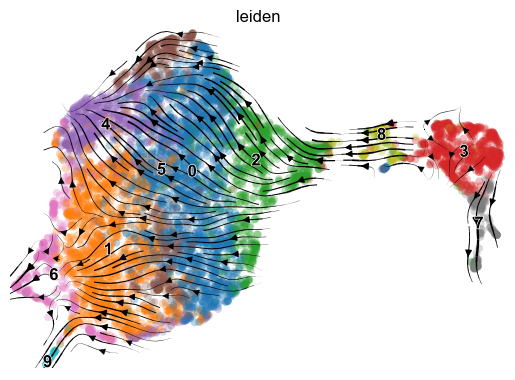

In [20]:
scv.pl.velocity_embedding_stream(adata_concat, basis='umap', color="leiden")

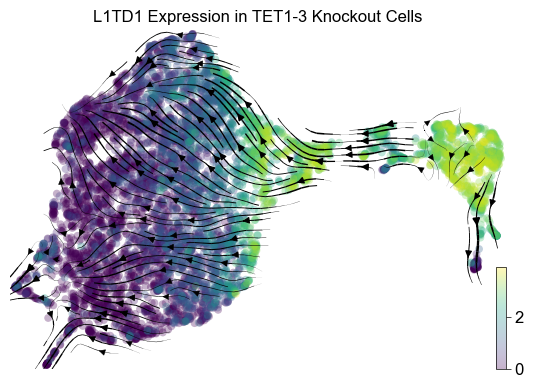

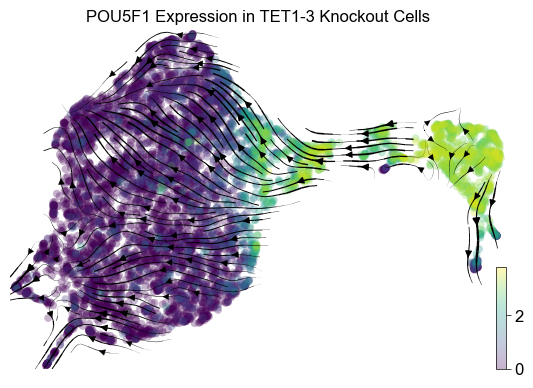

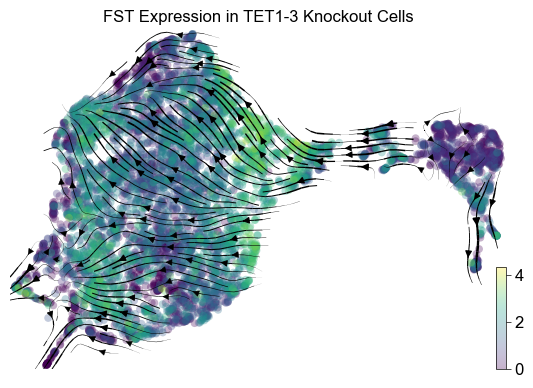

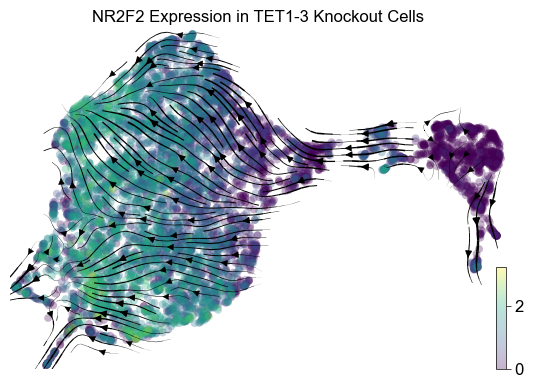

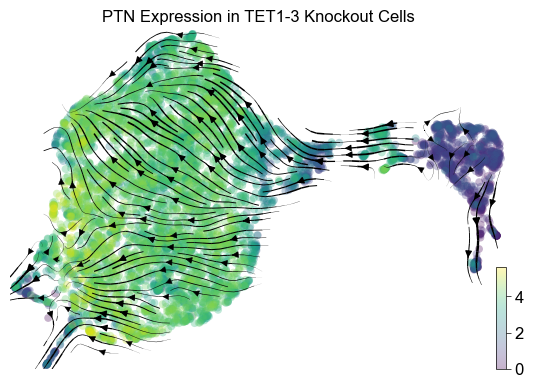

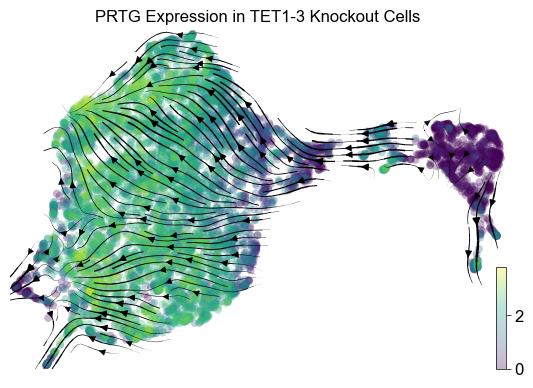

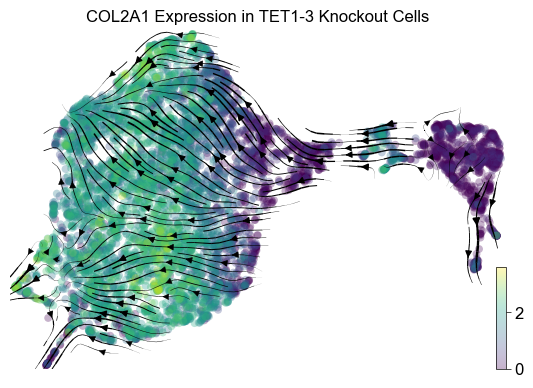

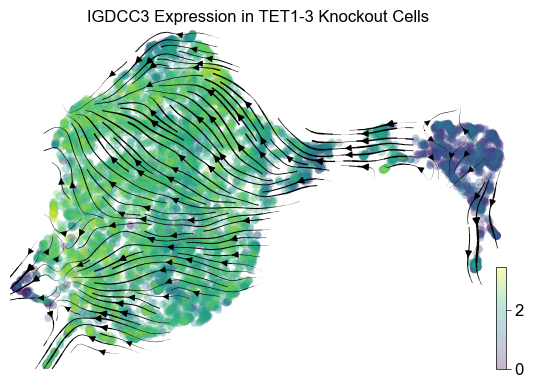

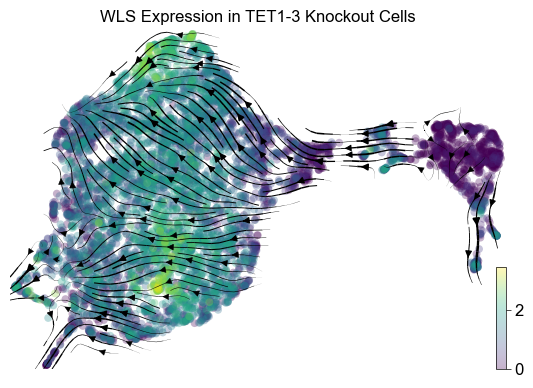

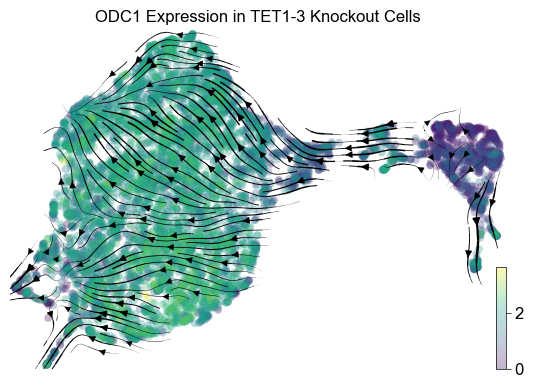

'\nfig,ax = plt.subplots(figsize=(2,2))\nscv.pl.velocity_embedding_stream(\n    adata_concat,\n    basis=\'umap\',\n    color="POU5F1",\n    ax=ax,\n    title=\'POU5F1 Expression in TET1-3 Knockout Cells\',\n    linewidth=0.25,\n    arrow_size=0.25,\n    size=3\n)\n\npath_out = \'figures/rna_velocity.svg\'\n\nfig.savefig(path_out)\n'

In [28]:
genes=['POU5F1', 'NR2F2', 'ZBTB16', 'EFCC1', 'FZD10-AS1', 'CNTFR', 'CUEDC1', 'MAGI2-AS3', 'FZD10', 'FRZB', 'NPAS3', 'NR2F1-AS1', 'NRGN', 'SCD5']

genes=['L1TD1', 'POU5F1', 'NR2F2', 'CNTFR', 'CUEDC1', 'FRZB', 'PAX6', 'FST']

genes=['L1TD1', 'POU5F1', 'FST', 'NR2F2', 'PTN', 'PRTG', 'COL2A1', 'IGDCC3', 'WLS', 'ODC1']

for gene in genes:
    scv.pl.velocity_embedding_stream(
        adata_concat,
        basis='umap',
        color=gene,
        title=f'{gene} Expression in TET1-3 Knockout Cells',
    )

'''
fig,ax = plt.subplots(figsize=(2,2))
scv.pl.velocity_embedding_stream(
    adata_concat,
    basis='umap',
    color="POU5F1",
    ax=ax,
    title='POU5F1 Expression in TET1-3 Knockout Cells',
    linewidth=0.25,
    arrow_size=0.25,
    size=3
)

path_out = 'figures/rna_velocity.svg'

fig.savefig(path_out)
'''

In [30]:
# save!
fn = f'scvi_integrated_{dataset}_tko.h5ad'
adata_concat.write_h5ad(fn, compression='gzip')

In [23]:
sc.tl.dendrogram(adata_concat, groupby='leiden')
#sc.tl.rank_genes_groups(adata_concat, groupby="leiden", method="wilcoxon")

sc.tl.rank_genes_groups(adata_concat, groupby='leiden', groups=['8', '2'], method='wilcoxon', reference='3')

categories: 0, 1, 2, etc.
var_group_labels: 8, 2


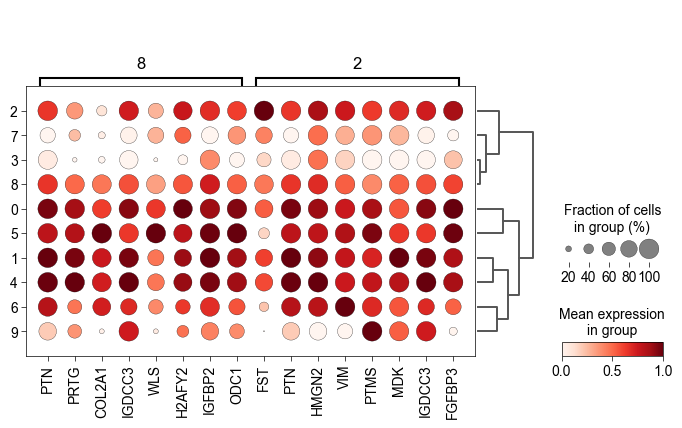

In [24]:
rc('font', size=12)    # fontsize of the tick labels
sc.pl.rank_genes_groups_dotplot(adata_concat, n_genes=8, standard_scale="var")

In [26]:
scv.tl.rank_velocity_genes(adata_concat, groupby='leiden', min_corr=.3)
df = pd.DataFrame(adata_concat.uns['rank_velocity_genes']['names'])
df.head()

ranking velocity genes
    finished (0:02:32) --> added 
    'rank_velocity_genes', sorted scores by group ids (adata.uns) 
    'spearmans_score', spearmans correlation scores (adata.var)


,0,1,2,3,4,5,6,7,8,9
0,CPE,RP11-32K4.1,RUNX1,TDGF1,NR2F1-AS1,RMST,PDGFC,ATP2B1,TDGF1,AC011306.2
1,SOX5,NCKAP5,LIMCH1,FLT1,NR2F2-AS1,LINC00907,ERBB4,SEMA6A,CDC42EP3,SLC1A2
2,NETO2,EPHA3,NRP2,ELAVL2,NTRK2,SOX6,LINC00478,NFIA,PFKP,ELAVL2
3,ASXL3,RP11-314P15.2,L1TD1,DST,NPAS3,DACH1,THSD7A,PCDH10,WFDC2,ZNF804A
4,PSD3,PIP5K1B,EPB41L3,SPATS2L,RP11-122D10.1,TFPI,LINC00907,TNC,CTNNBIP1,SRRM4


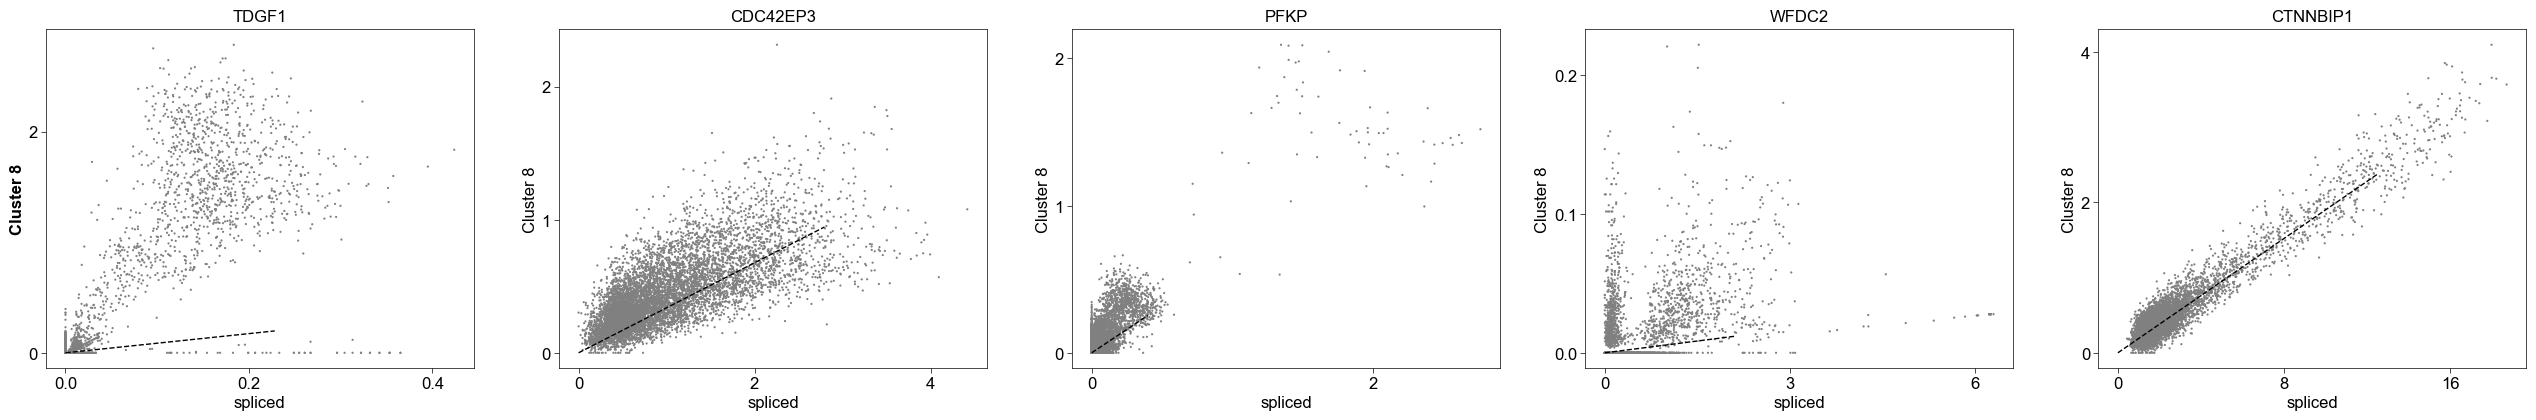

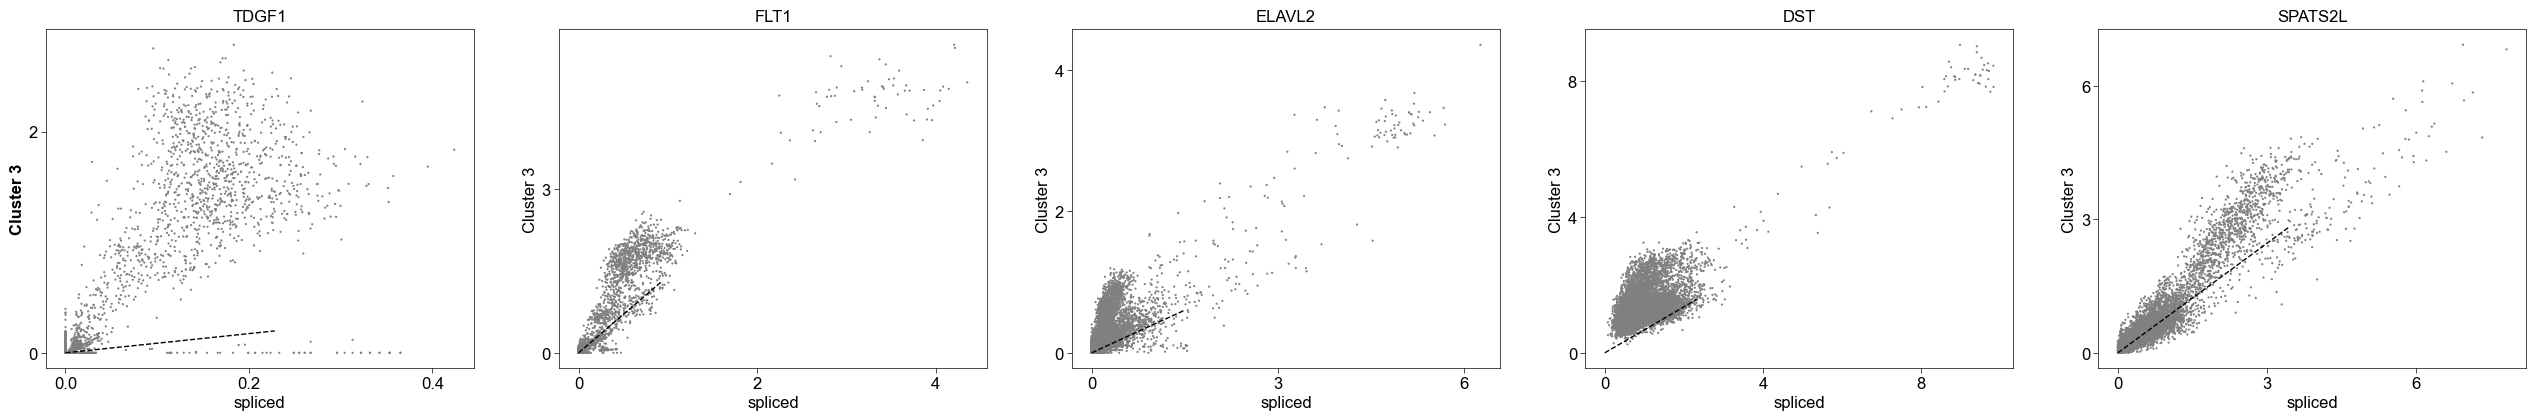

In [27]:
kwargs = dict(frameon=False, size=10, linewidth=1.5,
              add_outline='2, 3, 0')

scv.pl.scatter(adata_concat, df['8'][:5], ylabel='Cluster 8', size=10)
scv.pl.scatter(adata_concat, df['3'][:5], ylabel='Cluster 3', size=10)